# SCOPE

This notebook demonstrates `compute_xi` on a uniform Poisson random field.

## Sub-volume model

Each **sub-volume** is an independent statistical realisation that spans the **full
simulation box** at 1/k of the total number density (e.g. a single GALFORM run
out of k runs on the same N-body backbone). Stacking all k realisations recovers
the full-density catalogue. Selecting m < k realisations introduces a bias that
SCOPE corrects via the α/β weights of Hickman et al. (2026).

Note that sub-volume IDs are **not** spatial cell labels — galaxies in any given
sub-volume are distributed across the entire box.

For a Poisson field the true correlation function is ξ(r) = 0, so this is a
clean null test showing the correction removes the selection bias for all m.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scope import compute_xi

## 1. Simulation parameters

In [2]:
RNG_SEED = 42
BOX_SIZE = 542.16    # Mpc/h  (P-Millennium box)
N_FULL   = 200_000  # total galaxies across all k realisations
K        = 27       # number of independent realisations

# 20 log-spaced radial bins from 1 to 50 Mpc/h
R_BINS = np.logspace(np.log10(1.0), np.log10(50.0), 21)

rng = np.random.default_rng(RNG_SEED)

## 2. Generate the full catalogue and assign sub-volume IDs

Each galaxy is assigned to one of k realisations at random — sub-volume IDs are
independent of spatial position, so every realisation samples the full box volume
at density n/k.

In [3]:
coords_full  = rng.uniform(0, BOX_SIZE, size=(N_FULL, 3)).astype(np.float64)
sv_ids_full  = rng.integers(0, K, size=N_FULL, dtype=np.int32)

counts = np.bincount(sv_ids_full, minlength=K)
print(f"Full catalogue: {N_FULL:,} galaxies across {K} realisations")
print(f"Galaxies per realisation: min={counts.min()}, mean={counts.mean():.0f}, max={counts.max()}")

Full catalogue: 200,000 galaxies across 27 realisations
Galaxies per realisation: min=7191, mean=7407, max=7565


## 3. Run `compute_xi` for several values of m

For each m we randomly select m of the k realisation IDs, mask the catalogue to
those galaxies, and call `compute_xi`. The correction weights α and β are
computed internally.

In [4]:
M_VALUES = [2, 4, 8, 27]
results  = {}

for m in M_VALUES:
    chosen = rng.choice(K, size=m, replace=False)

    mask   = np.isin(sv_ids_full, chosen)
    coords = np.ascontiguousarray(coords_full[mask])
    sv_ids = np.ascontiguousarray(sv_ids_full[mask])

    res = compute_xi(
        coords             = coords,
        subvol_ids         = sv_ids,
        r_bins             = R_BINS,
        box_size           = BOX_SIZE,
        n_subvols          = K,
        n_subvols_selected = m,
    )
    results[m] = res
    print(f"m={m:2d}  N_sel={mask.sum():6,}  max|ξ| = {np.max(np.abs(res['xi'])):.4f}")

m= 2  N_sel=14,810  max|ξ| = 0.7385
m= 4  N_sel=29,577  max|ξ| = 0.3586
m= 8  N_sel=59,385  max|ξ| = 0.1091
m=27  N_sel=200,000  max|ξ| = 0.0272


## 4. Pair-count breakdown for m = 8

Because sub-volumes span the full box, both auto and cross pairs appear at
all separations. The corrected DD closely tracks the analytic RR, giving ξ ≈ 0.

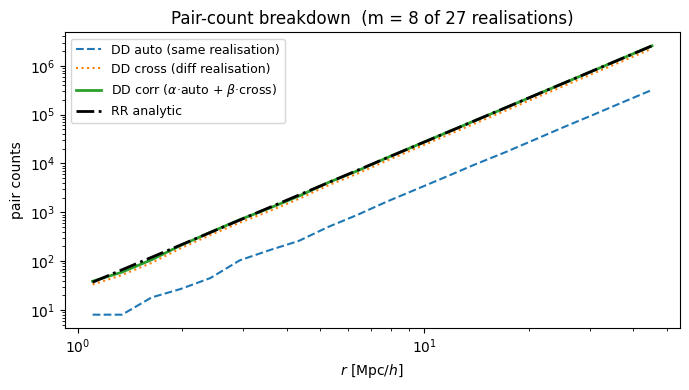

In [5]:
r = results[8]["r_mid"]

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(r, results[8]["dd_auto"],  label="DD auto (same realisation)",  ls="--")
ax.loglog(r, results[8]["dd_cross"], label="DD cross (diff realisation)", ls=":")
ax.loglog(r, results[8]["dd_corr"],  label=r"DD corr ($\alpha$·auto + $\beta$·cross)", lw=2)
ax.loglog(r, results[8]["rr"],       label="RR analytic", lw=2, ls="-.", color="k")
ax.set_xlabel(r"$r$ [Mpc/$h$]")
ax.set_ylabel("pair counts")
ax.set_title("Pair-count breakdown  (m = 8 of 27 realisations)")
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 5. ξ(r) for all m values

All curves should scatter around zero — the correction removes the sub-volume
selection bias regardless of m. Shot noise increases as m (and hence N_sel)
decreases.

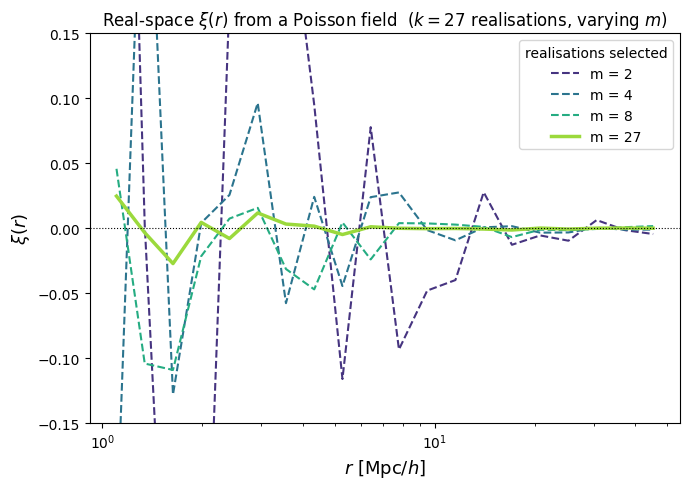

Saved xi_poisson.png


In [6]:
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(M_VALUES)))

fig, ax = plt.subplots(figsize=(7, 5))

for m, col in zip(M_VALUES, colors):
    r  = results[m]["r_mid"]
    xi = results[m]["xi"]
    lw = 2.5 if m == K else 1.5
    ls = "-"  if m == K else "--"
    ax.semilogx(r, xi, color=col, lw=lw, ls=ls, label=f"m = {m}")

ax.axhline(0, color="k", lw=0.8, ls=":")
ax.set_xlabel(r"$r$ [Mpc/$h$]", fontsize=13)
ax.set_ylabel(r"$\xi(r)$", fontsize=13)
ax.set_title(
    r"Real-space $\xi(r)$ from a Poisson field  "
    r"($k=27$ realisations, varying $m$)",
    fontsize=12,
)
ax.set_ylim(-0.15, 0.15)
ax.legend(title="realisations selected", fontsize=10)
fig.tight_layout()
plt.show()
print("Saved xi_poisson.png")

## 6. Noise convergence with m

RMS ξ across all bins decreases as m grows, because the effective sample size
grows as m/k of the full catalogue.

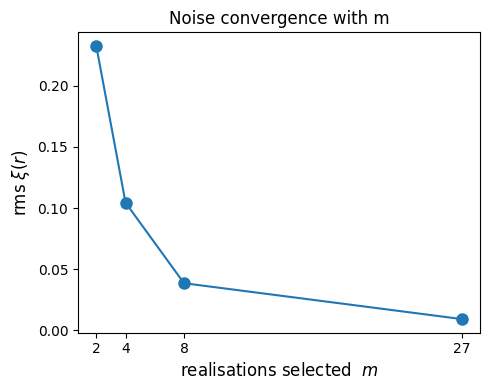

In [7]:
rms = [np.sqrt(np.mean(results[m]["xi"] ** 2)) for m in M_VALUES]

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(M_VALUES, rms, "o-", ms=8)
ax.set_xlabel("realisations selected  $m$", fontsize=12)
ax.set_ylabel(r"rms $\xi(r)$", fontsize=12)
ax.set_title("Noise convergence with m", fontsize=12)
ax.set_xticks(M_VALUES)
fig.tight_layout()
plt.show()